# 06 - Lead-Time Tests and Dashboard Export

Purpose:
- test whether gold alarms precede traditional risk deterioration;
- quantify false alarms and missed events;
- export a dashboard-ready table combining alarm state, VaR, drawdown, and stress-test recommendation.

This notebook is the key discipline check: the dashboard premise should be evaluated, not assumed.

## Reader Orientation

This notebook evaluates the dashboard as a nowcasting and escalation tool. Lead time is useful, but it is not the whole premise. A valid nowcasting signal may fire before, during, or near the period when traditional risk measures begin to show deterioration.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step06"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
riskbook_path = PROCESSED_DIR / "riskbook_var_core.parquet"
if not riskbook_path.exists():
    riskbook_path = PROCESSED_DIR / "riskbook_var.parquet"

stress_path = ROOT / "outputs" / "step05" / "stress_scenarios_core.csv"

riskbook = pd.read_parquet(riskbook_path)
stress_scenarios = pd.read_csv(stress_path) if stress_path.exists() else pd.DataFrame()

required_cols = ["R_book", "nav", "drawdown", "hs_var_return", "var_breach", "realized_vol_20d", "gold_alarm", "alarm_score", "dashboard_state"]
missing_cols = [col for col in required_cols if col not in riskbook.columns]
if missing_cols:
    raise ValueError(f"Missing expected Step 05 columns: {missing_cols}")

print("Loaded riskbook:", riskbook_path, riskbook.shape)
riskbook.tail()


Loaded riskbook: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\riskbook_var_core.parquet (4090, 11)


,R_book,nav,drawdown,realized_vol_20d,gold_alarm,alarm_score,dashboard_state,hs_var_return,hs_es_return,var_breach,excess_loss_over_var
Date,,,,,,,,,,,
2026-05-26,-0.038997,40.279864,-0.733383,0.623301,0,1,Amber,-0.041646,-0.085581,0,-0.002649
2026-05-27,-0.054586,38.081139,-0.747937,0.635885,0,1,Amber,-0.041646,-0.085581,1,0.012940
2026-05-28,-0.006170,37.846169,-0.749492,0.584325,0,1,Amber,-0.044967,-0.086520,0,-0.038796
2026-05-29,-0.017873,37.169746,-0.753969,0.578528,0,1,Amber,-0.044967,-0.086520,0,-0.027094
2026-06-01,0.031334,38.334439,-0.746260,0.574621,0,1,Amber,-0.044967,-0.086520,0,-0.076301


In [3]:
LOOKBACK_DAYS = 30
COOLDOWN_DAYS = 5
DRAWDOWN_EVENT_LEVEL = -0.05
VOL_Z_THRESHOLD = 2.0


## Helper Functions

A lead-time test should operate on event starts, not every day inside the same event cluster.

In [4]:
def trailing_zscore(series: pd.Series, window: int) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


def apply_cooldown(flag: pd.Series, cooldown_days: int) -> pd.Series:
    cooled = pd.Series(0, index=flag.index, dtype=int)
    last_fire = None
    for date, value in flag.fillna(0).astype(int).items():
        if value != 1:
            continue
        if last_fire is None or (date - last_fire).days > cooldown_days:
            cooled.loc[date] = 1
            last_fire = date
    return cooled


def match_leads(alarm_dates: pd.DatetimeIndex, event_dates: pd.DatetimeIndex, lookback_days: int) -> pd.DataFrame:
    rows = []
    for event_date in event_dates:
        candidates = alarm_dates[
            (alarm_dates <= event_date)
            & (alarm_dates >= event_date - pd.Timedelta(days=lookback_days))
        ]
        if len(candidates) == 0:
            rows.append({
                "event_date": event_date,
                "matched": False,
                "alarm_date": pd.NaT,
                "lead_days": np.nan,
            })
        else:
            alarm_date = candidates[-1]
            rows.append({
                "event_date": event_date,
                "matched": True,
                "alarm_date": alarm_date,
                "lead_days": (event_date - alarm_date).days,
            })
    return pd.DataFrame(rows)


### Why Event Starts Matter

The lead-time test should count episodes, not every day inside a continuing stress period. Event starts and alarm cooldowns reduce double-counting and make the timing test closer to how an operational dashboard would be used.

## Define Traditional Risk Events

The gold alarm is compared against three conventional risk deterioration anchors:
- VaR breach episodes;
- portfolio volatility spikes;
- drawdown threshold events.

In [5]:
analysis = riskbook.copy()
analysis["cooled_gold_alarm"] = apply_cooldown(analysis["gold_alarm"], COOLDOWN_DAYS)

vol_z = trailing_zscore(analysis["realized_vol_20d"], 252)
analysis["portfolio_vol_z"] = vol_z
analysis["portfolio_vol_spike"] = (vol_z > VOL_Z_THRESHOLD).astype(int)
analysis["drawdown_event"] = (analysis["drawdown"] <= DRAWDOWN_EVENT_LEVEL).astype(int)

alarm_dates = event_starts(analysis["cooled_gold_alarm"])
event_families = {
    "var_breach": event_starts(analysis["var_breach"]),
    "portfolio_vol_spike": event_starts(analysis["portfolio_vol_spike"]),
    "drawdown_event": event_starts(analysis["drawdown_event"]),
}

print("Alarm starts:", len(alarm_dates))
for family, dates in event_families.items():
    print(family, len(dates))


Alarm starts: 166
var_breach 198
portfolio_vol_spike 21
drawdown_event 15


### Result Comment And Significance

In the latest run, the cooled gold alarm starts 166 times. Traditional risk anchors include 198 VaR breach episodes, 21 portfolio volatility spike episodes, and 15 drawdown episodes. This already shows the main evaluation challenge: the alarm is active often enough to be useful, but also often enough that false-alarm control matters.

## Lead-Time Tables

A matched event means a cooled gold alarm fired within the lookback window before the risk event.

### Nowcasting Versus Early-Warning Interpretation

The current lead-time table is useful evidence, but it should not be interpreted as the only success criterion. For nowcasting, a signal can be valuable if it fires before or around a VaR breach, volatility spike, or drawdown event. A later refinement should add a contemporaneous hit test using windows around the risk event, not only pre-event matching.

In [6]:
lead_tables = []
for family, dates in event_families.items():
    table = match_leads(alarm_dates, dates, LOOKBACK_DAYS)
    table["event_family"] = family
    lead_tables.append(table)

lead_time_table = pd.concat(lead_tables, ignore_index=True) if lead_tables else pd.DataFrame()

lead_summary = (
    lead_time_table
    .groupby("event_family")
    .agg(
        event_count=("event_date", "count"),
        matched_count=("matched", "sum"),
        match_rate=("matched", "mean"),
        avg_lead_days=("lead_days", "mean"),
        median_lead_days=("lead_days", "median"),
    )
    .reset_index()
)

lead_summary


,event_family,event_count,matched_count,match_rate,avg_lead_days,median_lead_days
0,drawdown_event,15,5,0.333333,12.8000,14.0
1,portfolio_vol_spike,21,16,0.761905,9.4375,9.0
2,var_breach,198,120,0.606061,8.1750,6.0


### Result Comment And Significance

The latest lead-time results are mixed but useful. Gold alarms matched about 60.6% of VaR breach episodes with an average lead of about 8.2 days, and about 76.2% of portfolio volatility spike episodes with an average lead of about 9.4 days. Drawdown-event matching is weaker, about 33.3%, but matched cases had about 12.8 days of average lead. This supports an escalation-signal framing, not a perfect predictor framing.

## False-Alarm Proxy

A false alarm is defined here as a cooled gold alarm that is not followed by any selected traditional risk event within the same business window. This is a proxy, not a final production rule.

In [7]:
all_events = pd.DatetimeIndex(sorted(set().union(*[set(v) for v in event_families.values()])))
false_alarm_rows = []

for alarm_date in alarm_dates:
    future_events = all_events[
        (all_events >= alarm_date)
        & (all_events <= alarm_date + pd.Timedelta(days=LOOKBACK_DAYS))
    ]
    false_alarm_rows.append({
        "alarm_date": alarm_date,
        "followed_by_event": len(future_events) > 0,
        "next_event_date": future_events[0] if len(future_events) else pd.NaT,
    })

false_alarm_table = pd.DataFrame(false_alarm_rows)
false_alarm_summary = pd.DataFrame([{
    "alarm_count": len(false_alarm_table),
    "false_alarm_count": int((~false_alarm_table["followed_by_event"]).sum()) if len(false_alarm_table) else 0,
    "false_alarm_rate": float((~false_alarm_table["followed_by_event"]).mean()) if len(false_alarm_table) else np.nan,
}])

false_alarm_summary


,alarm_count,false_alarm_count,false_alarm_rate
0,166,53,0.319277


### Result Comment And Significance

The latest false-alarm proxy is about 31.9%. That is not fatal for an escalation dashboard, but it is too high to ignore. The final project should discuss whether this is acceptable for a review trigger and should consider persistence, cooldown, or threshold calibration to reduce unnecessary alerts.

## Dashboard Export

The dashboard table combines the gold alarm state, conventional risk measures, and recommended action. Stress-test scenarios are not repeated row-by-row; they are saved separately from Step 05.

In [8]:
dashboard = analysis[[
    "R_book",
    "nav",
    "drawdown",
    "hs_var_return",
    "hs_es_return",
    "var_breach",
    "realized_vol_20d",
    "portfolio_vol_z",
    "portfolio_vol_spike",
    "gold_alarm",
    "cooled_gold_alarm",
    "alarm_score",
    "dashboard_state",
]].copy()

dashboard["recommended_action"] = np.select(
    [
        dashboard["dashboard_state"].eq("Red"),
        dashboard["dashboard_state"].eq("Amber"),
    ],
    [
        "Run stress tests and review VaR calibration",
        "Monitor and inspect gold relationship components",
    ],
    default="Normal monitoring",
)

dashboard.tail()


,R_book,nav,drawdown,hs_var_return,hs_es_return,var_breach,realized_vol_20d,portfolio_vol_z,portfolio_vol_spike,gold_alarm,cooled_gold_alarm,alarm_score,dashboard_state,recommended_action
Date,,,,,,,,,,,,,,
2026-05-26,-0.038997,40.279864,-0.733383,-0.041646,-0.085581,0,0.623301,0.822577,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-05-27,-0.054586,38.081139,-0.747937,-0.041646,-0.085581,1,0.635885,0.865824,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-05-28,-0.006170,37.846169,-0.749492,-0.044967,-0.086520,0,0.584325,0.658151,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-05-29,-0.017873,37.169746,-0.753969,-0.044967,-0.086520,0,0.578528,0.630614,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-06-01,0.031334,38.334439,-0.746260,-0.044967,-0.086520,0,0.574621,0.610506,0,0,0,1,Amber,Monitor and inspect gold relationship components


### Dashboard Significance

The dashboard table combines signal state and traditional risk measures. The important design principle is that Red does not mean 'loss is certain'; it means 'run stress tests and review VaR calibration.' That is a defensible operational use of a noisy cross-market signal.

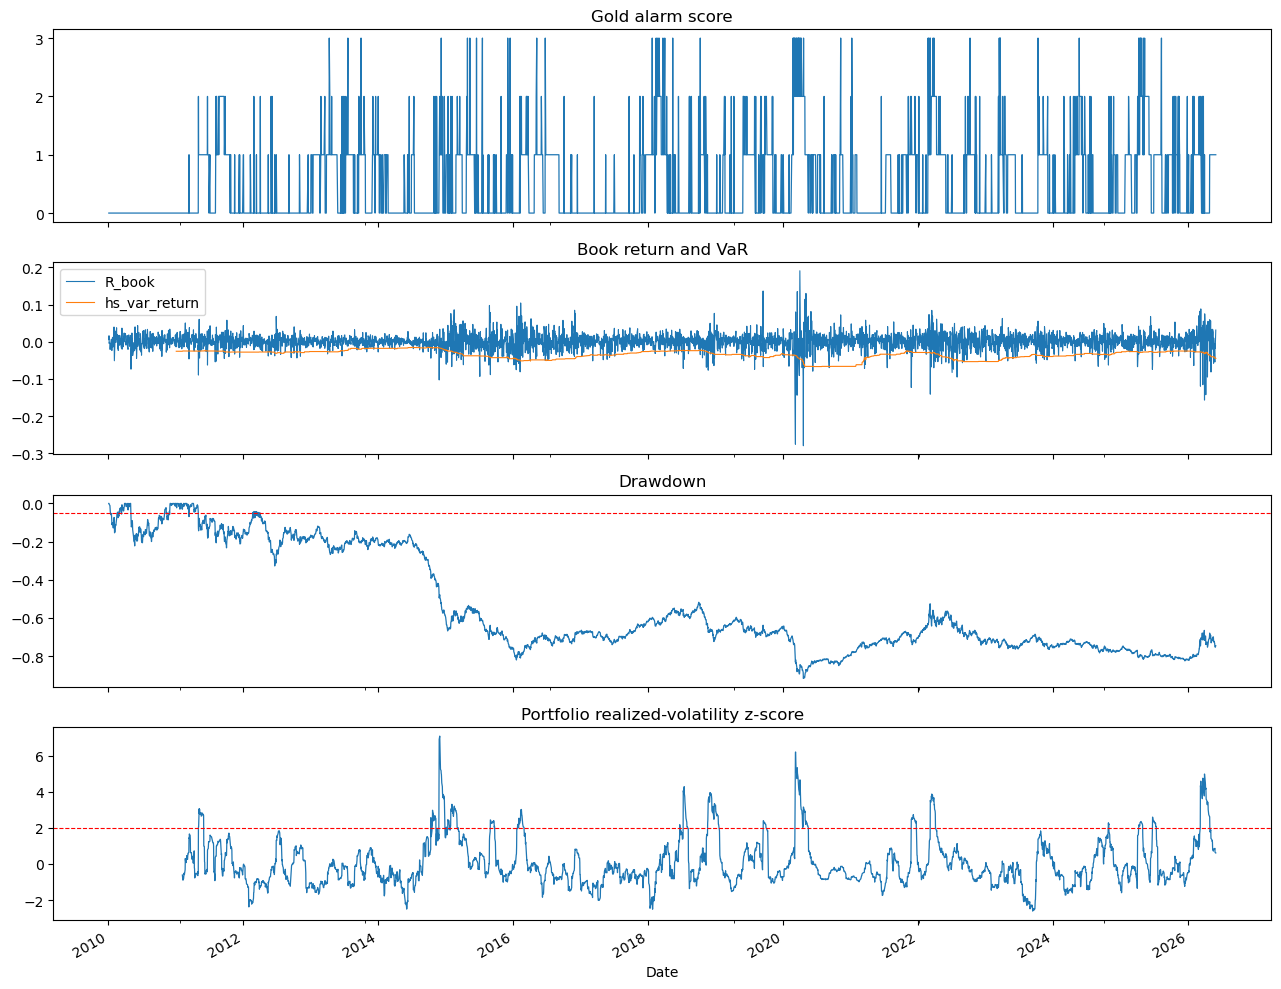

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

analysis["alarm_score"].plot(ax=axes[0], linewidth=0.9)
axes[0].set_title("Gold alarm score")

analysis[["R_book", "hs_var_return"]].plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Book return and VaR")

analysis["drawdown"].plot(ax=axes[2], linewidth=0.9)
axes[2].axhline(DRAWDOWN_EVENT_LEVEL, color="red", linestyle="--", linewidth=0.8)
axes[2].set_title("Drawdown")

analysis["portfolio_vol_z"].plot(ax=axes[3], linewidth=0.9)
axes[3].axhline(VOL_Z_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[3].set_title("Portfolio realized-volatility z-score")

plt.tight_layout()


## Step 06 Working Takeaways

- This notebook tests the alarm as an escalation signal rather than assuming it works.
- The key outputs are match rate, lead time, and false-alarm rate.
- A useful dashboard signal does not need perfect prediction, but it must not fire so often that users ignore it.

### What This Still Does Not Fully Prove

This notebook supports the escalation-dashboard premise, but it does not yet fully prove the final project claim. It still needs a formal nowcasting-window hit rate, comparison against naive baselines such as VIX-only or Brent-vol-only triggers, and event-window case studies. Those are the next validation steps before the dashboard claim is final.

In [10]:
lead_time_table.to_csv(OUTPUT_DIR / "lead_time_table.csv", index=False)
lead_summary.to_csv(OUTPUT_DIR / "lead_time_summary.csv", index=False)
false_alarm_table.to_csv(OUTPUT_DIR / "false_alarm_table.csv", index=False)
false_alarm_summary.to_csv(OUTPUT_DIR / "false_alarm_summary.csv", index=False)
dashboard.to_csv(OUTPUT_DIR / "dashboard_metrics.csv")

if not stress_scenarios.empty:
    stress_scenarios.to_csv(OUTPUT_DIR / "dashboard_stress_scenarios.csv", index=False)

print("Saved Step 06 lead-time and dashboard outputs to:", OUTPUT_DIR)


Saved Step 06 lead-time and dashboard outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step06
